#### Load data and import lib

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

In [2]:
from ydata_profiling import ProfileReport

#### Clean Dataset load and numeric_col and catagorical_col spearte

In [3]:
df = pd.read_csv("cleaned_property_dataset.csv", low_memory=False)

In [4]:
df.head()

,id,parcel_id,property_house_num,property_fraction,property_address,property_city,property_state,property_unit,property_zip,municipality_code,...,full_baths,half_baths,heating_cooling,heating_cooling_desc,fireplaces,basement_garage,finished_living_area,card_number,tax_year,as_of_date
0,26660041,0001D00125000000,100.0,,5TH AVE,PITTSBURGH,PA,,15222.0,101,...,1.502875,0.494164,B,Central Heat with AC,0.376731,0.705458,1714.06402,1.003815,2026,2026-04-01
1,26660042,0001D00127000000,23.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,1.502875,0.494164,B,Central Heat with AC,0.376731,0.705458,1714.06402,1.003815,2026,2026-04-01
2,26660043,0001D00128000000,24.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,1.502875,0.494164,B,Central Heat with AC,0.376731,0.705458,1714.06402,1.003815,2026,2026-04-01
3,26660044,0001D00130000000,26.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,...,1.502875,0.494164,B,Central Heat with AC,0.376731,0.705458,1714.06402,1.003815,2026,2026-04-01
4,26660045,0001D00132000000,115.0,-119,FORBES AVE,PITTSBURGH,PA,,15222.0,101,...,1.502875,0.494164,B,Central Heat with AC,0.376731,0.705458,1714.06402,1.003815,2026,2026-04-01


In [5]:
df.tail()

,id,parcel_id,property_house_num,property_fraction,property_address,property_city,property_state,property_unit,property_zip,municipality_code,...,full_baths,half_baths,heating_cooling,heating_cooling_desc,fireplaces,basement_garage,finished_living_area,card_number,tax_year,as_of_date
584891,27244932,0887C00325000000,6127.0,,PLEASANT ST,SOUTH PARK,PA,,15129.0,945,...,1.0,1.0,B,Central Heat with AC,0.0,0.0,1045.0,1.0,2026,2026-04-01
584892,27244933,0772H00012000000,942.0,,WESTCHESTER RD,SOUTH PARK,PA,,15129.0,945,...,2.0,0.0,B,Central Heat with AC,1.0,2.0,1338.0,1.0,2026,2026-04-01
584893,27244934,0320D00137000000,565.0,,MIRANDA RD,PITTSBURGH,PA,,15241.0,950,...,2.0,2.0,B,Central Heat with AC,1.0,2.0,2712.0,1.0,2026,2026-04-01
584894,27244935,0319G00008000000,4.0,,MITCHELL DR,PITTSBURGH,PA,,15241.0,950,...,1.0,0.0,B,Central Heat with AC,1.0,1.0,1246.0,1.0,2026,2026-04-01
584895,27244936,0884E00015000000,1230.0,,BARNSTAPLE DR,SOUTH PARK,PA,,15129.0,945,...,2.0,1.0,B,Central Heat with AC,0.0,2.0,1872.0,1.0,2026,2026-04-01


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [7]:
df[cat_cols].value_counts()

parcel_id         property_fraction  property_address  property_city  property_state  property_unit  municipality_desc       school_desc     legal_description_1                              legal_description_2                              neighborhood_code  neighborhood_desc         tax_code  tax_desc      owner_desc              property_class  property_class_desc  use_desc              record_date  sale_date   sale_code  sale_desc        deed_book  deed_page  prev_sale_date  change_notice_address_1          change_notice_address_2  change_notice_address_3  building_style  building_style_desc  exterior_finish_desc  roof_desc  basement_desc  grade  grade_desc   condition_desc  cdu_code  cdu_desc  heating_cooling  heating_cooling_desc  as_of_date
0001A00100000000                     COMMONWEALTH PL   PITTSBURGH     PA                             1st Ward  - PITTSBURGH  Pittsburgh      LOT 1925X183 FT PITT BLVD BET POINT & SHORT ST   178500 SQ FT ALLEGHENY WHARF POINT OF BARBEAU    51C02

In [8]:
df[num_cols].value_counts()

id        property_house_num  property_zip  municipality_code  school_code  owner_code  use_code  lot_area  sale_price  prev_sale_price  change_notice_address_4  county_building_value  county_land_value  county_total_value  county_exempt_building  local_building_value  local_land_value  local_total_value  fair_market_building  fair_market_land  fair_market_total  stories   year_built   exterior_finish  roof_type  basement_type  condition  total_rooms  bedrooms  full_baths  half_baths  fireplaces  basement_garage  finished_living_area  card_number  tax_year
26660041  100.0               15222.0       101                47           20          449       7510      1.0         700000.000000    43215.0                  466700                 422400             889100              0                       466700                422400            889100             466700                422400            889100             1.640284  1949.320652  2.145801         1.190076   4.757283       3.121

## Analysis Start Here
### These question we find the answer.
#### 1️⃣ Property Sale Analysis

Questions related to **property transactions**.

1. What is the **average sale price** of properties?
2. How does **sale_price vary by property_city**?
3. What is the **yearly trend of property sales** using `sale_date`?
4. How many properties were **sold each year**?
5. What is the **highest and lowest sale price** recorded?
6. What is the **distribution of sale_price**?
7. How does **previous sale price compare with current sale price**?
8. What percentage of properties **increased in value** between sales?
9. Which **municipality has the highest average sale price**?
10. What is the **median sale price per tax_year**?

---

#### 2️⃣ Location-Based Analysis

Questions about **location impact on property value**.

11. Which **city has the most properties**?
12. Which **neighborhood has the highest average property value**?
13. What is the **average fair market value per municipality**?
14. Which **school district has the highest property values**?
15. What is the **distribution of properties by zip code**?
16. Which **neighborhood has the most expensive houses**?

---

#### 3️⃣ Property Characteristics Analysis

Questions about **physical characteristics of houses**.

17. How does **sale_price vary with number of bedrooms**?
18. Does **finished_living_area affect property price**?
19. What is the **average house size by city**?
20. How many **stories do most houses have**?
21. Which **building_style is most common**?
22. Does **roof type affect property value**?
23. How many houses **have basements**?
24. Do houses with **fireplaces sell for higher prices**?

---

#### 4️⃣ Property Age Analysis

Using `year_built`.

25. What is the **average age of properties**?
26. Do **newer houses sell for higher prices**?
27. How many properties were built **before 1950, 2000, etc.**?
28. What is the **distribution of construction years**?

---

#### 5️⃣ Tax Assessment Analysis

Questions about **property tax values**.

29. What is the **average county_total_value**?
30. How does **fair_market_total compare with sale_price**?
31. Which **city has the highest assessed property value**?
32. What percentage of properties have **tax exemptions**?
33. How do **county values compare with local values**?

---

#### 6️⃣ Land & Area Analysis

Using `lot_area` and `finished_living_area`.

34. What is the **average lot size by city**?
35. Do **larger lots lead to higher sale prices**?
36. What is the **relationship between living area and sale price**?
37. What is the **largest property lot_area**?

---

#### 7️⃣ Housing Quality Analysis

Using `grade`, `condition`, `cdu`.

38. How does **property condition affect sale price**?
39. Which **grade houses have the highest prices**?
40. What is the **most common housing condition**?
41. How does **building grade correlate with fair market value**?

---

#### 8️⃣ Feature-Based Analysis

House amenities.

42. Do houses with **basement_garage sell for more**?
43. Do houses with **more bathrooms sell for more**?
44. How many houses have **heating_cooling systems**?
45. Does **number of rooms impact sale price**?

---

#### 9️⃣ Time-Based Analysis

Using `record_date`, `sale_date`, `tax_year`.

46. What is the **trend of property values over time**?
47. How many properties were **recorded each year**?
48. What is the **average sale price per tax_year**?

---

#### 🔟 Data Quality Questions (EDA)

Important for **data preprocessing**.

49. Which columns have the **most missing values**?
50. Are there **duplicate parcel_id records**?
51. What is the **correlation between numeric features**?
52. Are there **outliers in sale_price**?
53. Are there **inconsistent values in property_city or zip codes**?

---

#### ⭐ Advanced Analysis Questions (Best for ML Projects)

54. Can we **predict sale_price using property features**?
55. What features most influence **property value**?
56. Can we **cluster neighborhoods based on property value**?
57. Can we detect **undervalued properties**?

---

## 1️⃣ Property Sale Analysis

In [ ]:
# 1. What is the **average sale price** of properties?
average_sale_price = df['sale_price'].mean()
print(f"Average Sale Price: ${average_sale_price:,.2f}")

Average Sale Price: $159,913.37


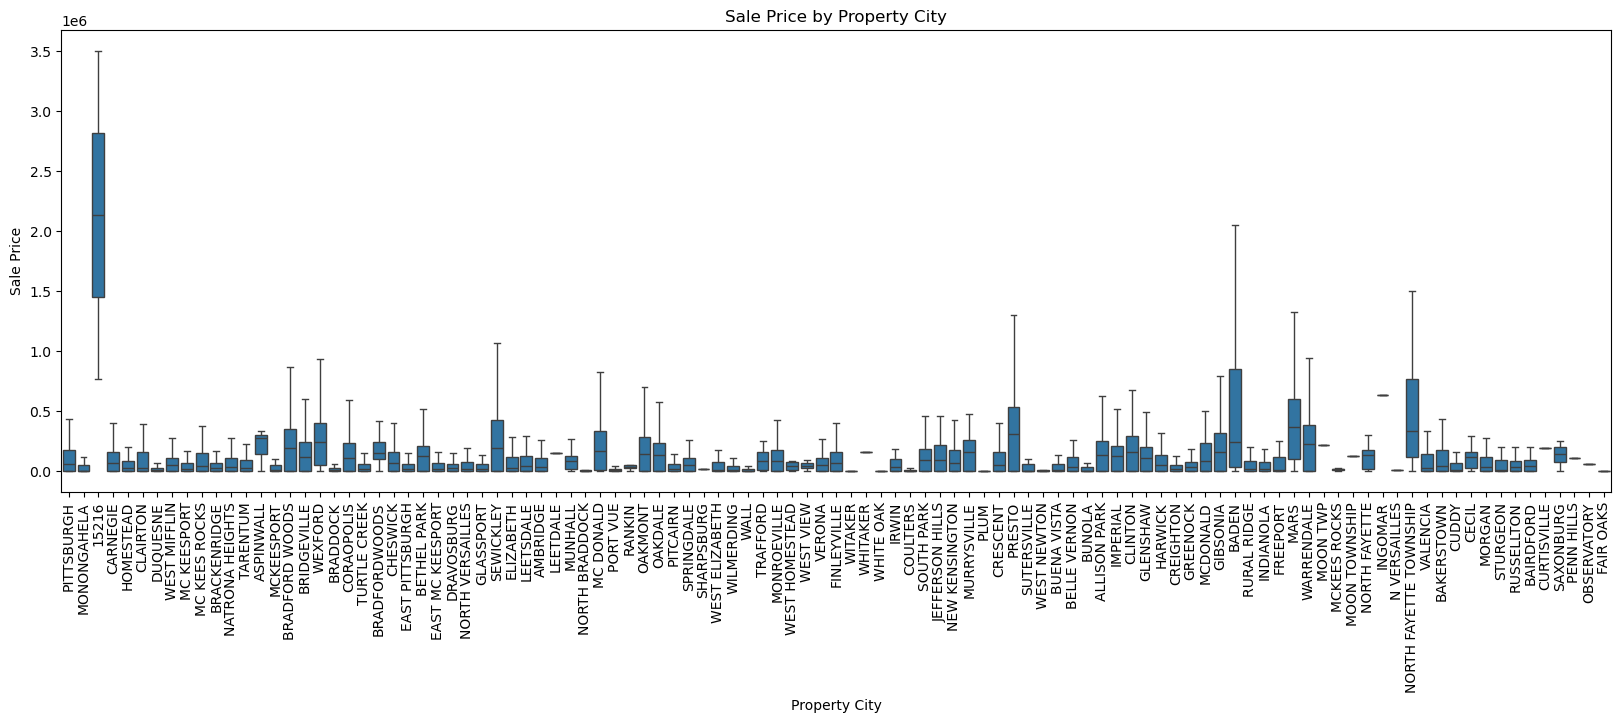

In [ ]:
# 2. How does **sale_price vary by property_city**?
plt.figure(figsize=(20,6))
sns.boxplot(x=df['property_city'], y=df['sale_price'], data=df, showfliers=False)
plt.title('Sale Price by Property City')
plt.xlabel('Property City')
plt.ylabel('Sale Price')
plt.xticks(rotation=90)
plt.show()


In [ ]:
# 3. What is the **yearly trend of property sales** using `sale_date`?
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['sale_year'] = df['sale_date'].dt.year

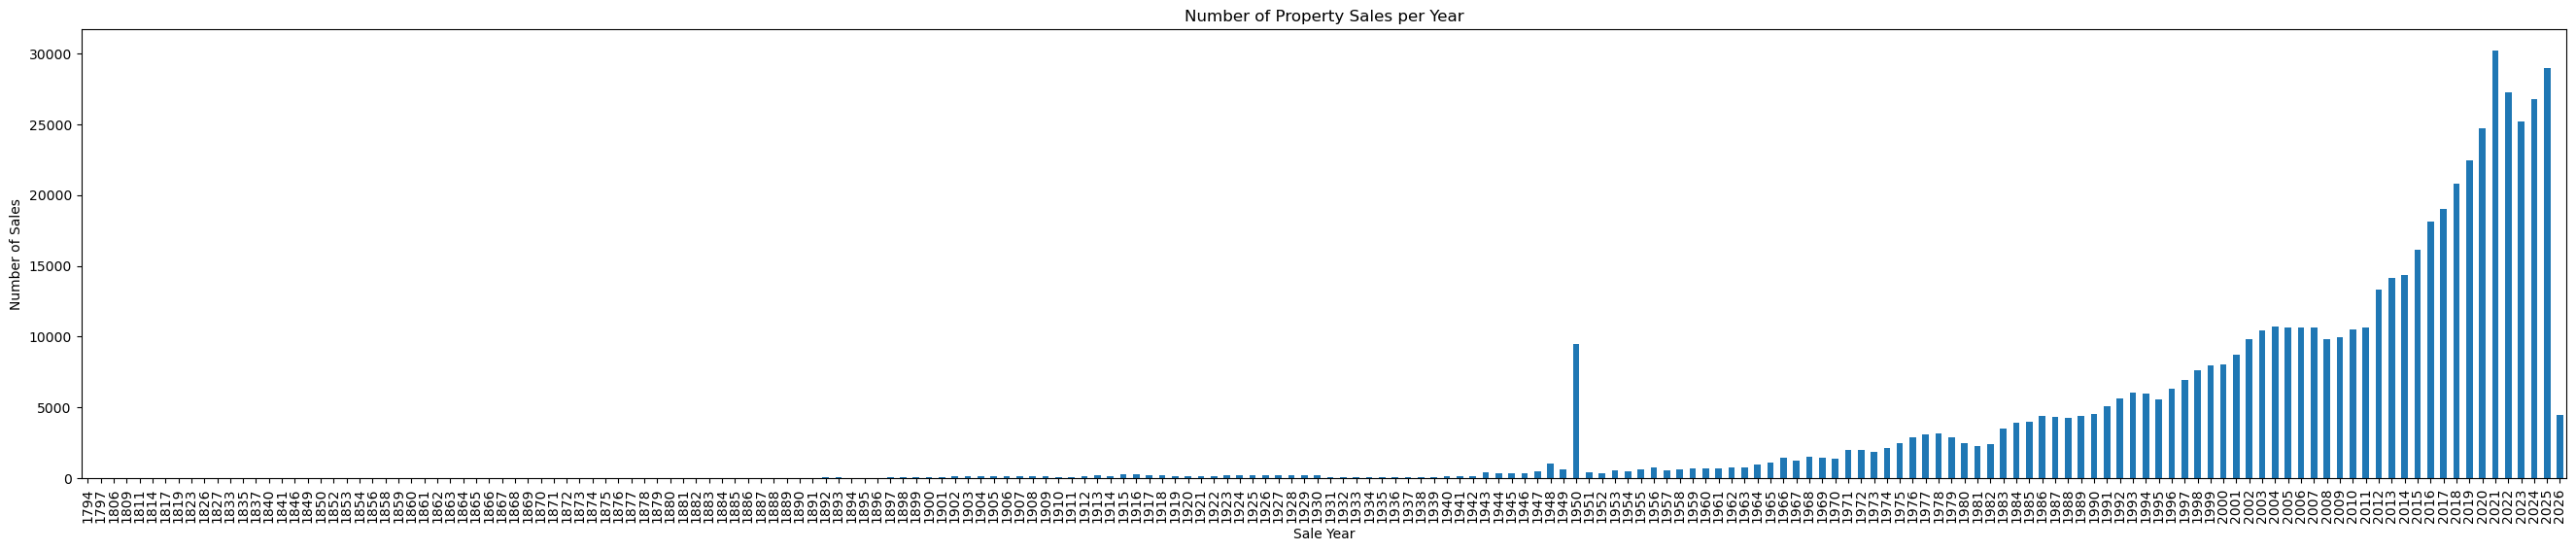

In [ ]:
plt.figure(figsize=(33,6))
df['sale_year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Property Sales per Year')
plt.xlabel('Sale Year')
plt.ylabel('Number of Sales')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# for set to show all rows in output
pd.set_option('display.max_rows', None)

# 4. How many properties were **sold each year**?
sales_per_year = df['sale_year'].value_counts().sort_index()
print("Number of Properties Sold Each Year:")
print(sales_per_year)

Number of Properties Sold Each Year:
sale_year
1794        1
1797        1
1806        1
1809        1
1811        1
1814        2
1817        1
1819        1
1823        1
1826        1
1827        1
1833        2
1835        2
1837        1
1840        1
1841        4
1846        1
1849        1
1850        2
1852        1
1853        2
1854        2
1856        1
1858        1
1859        4
1860        1
1861        2
1862        1
1863        5
1864        1
1865        3
1866        6
1867       10
1868        6
1869        5
1870        7
1871       12
1872       17
1873       16
1874       19
1875       25
1876        7
1877        6
1878        7
1879        4
1880        8
1881        8
1882       10
1883       10
1884       10
1885       15
1886       17
1887       16
1888       16
1889       32
1890       39
1891       49
1892       78
1893       62
1894       40
1895       45
1896       43
1897       56
1898       64
1899       83
1900      100
1901      104
1902      147
1

In [ ]:
# 5. What is the **highest and lowest sale price** recorded?
highest_sale_price = df['sale_price'].max()
lowest_sale_price = df['sale_price'].min()
print(f"Highest sale price: ${highest_sale_price:,.2f}")
print(f"Lowest sale price: ${lowest_sale_price:,.2f}")

Highest sale price: $179,395,660.00
Lowest sale price: $0.00


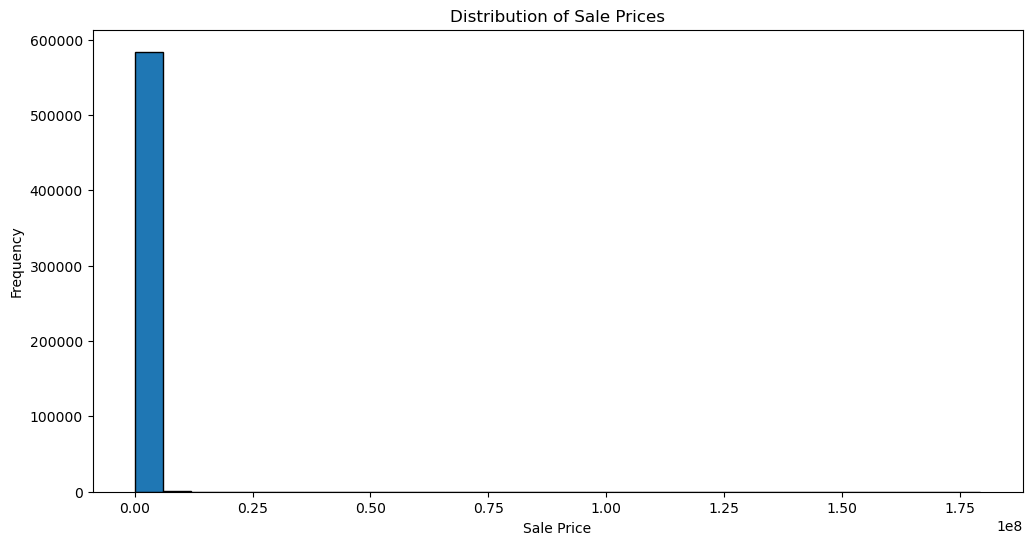

In [ ]:
# 6. What is the **distribution of sale_price**?
plt.figure(figsize=(12,6))
plt.hist(df['sale_price'], bins=30, edgecolor='black')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

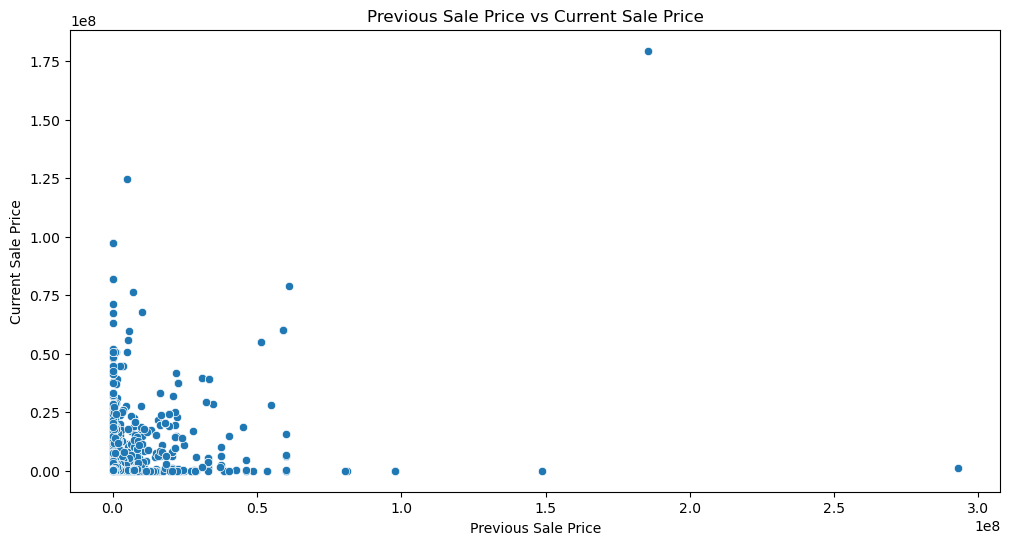

In [ ]:
# 7. How does **previous sale price compare with current sale price**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['prev_sale_price'], y=df['sale_price'])
plt.title('Previous Sale Price vs Current Sale Price')
plt.xlabel('Previous Sale Price')
plt.ylabel('Current Sale Price')
plt.show()

In [ ]:
# 8 . What percentage of properties **increased in value** between sales?
df['value_increase'] = df['sale_price'] > df['prev_sale_price']
value_increase_percentage = (df['value_increase'].sum() / len(df)) * 100
print(f"Percentage of properties that increased in value: {value_increase_percentage:.2f}%")

Percentage of properties that increased in value: 56.09%


In [ ]:
# 9. Which **municipality has the highest average sale price**?
avg_price_by_municipality = df.groupby('municipality_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Municipality:")
print(avg_price_by_municipality)

Average Sale Price by Municipality:
municipality_desc
2nd Ward - PITTSBURGH      1.059636e+06
22nd Ward - PITTSBURGH     7.897145e+05
1st Ward  - PITTSBURGH     7.477962e+05
Sewickley Heights          6.745936e+05
Edgeworth                  5.992898e+05
Aleppo                     5.538030e+05
Fox Chapel                 4.875986e+05
23rd Ward - PITTSBURGH     4.614080e+05
4th Ward - PITTSBURGH      4.498250e+05
Frazer                     3.983419e+05
Marshall                   3.949520e+05
Pine                       3.907674e+05
7th Ward - PITTSBURGH      3.632736e+05
25th Ward - PITTSBURGH     3.533131e+05
Sewickley                  3.501759e+05
6th Ward - PITTSBURGH      3.340417e+05
Harmar                     3.104709e+05
Rosslyn Farms              2.973035e+05
Glen Osborne               2.923896e+05
Ohio                       2.886352e+05
14th Ward - PITTSBURGH     2.815916e+05
Upper St. Clair            2.799671e+05
Findlay                    2.776623e+05
O''Hara                   

In [ ]:
# 10. What is the **median sale price per tax_year**?
median_price_by_tax_year = df.groupby('tax_year')['sale_price'].median().sort_index()
print("Median Sale Price per Tax Year:")
print(median_price_by_tax_year)


Median Sale Price per Tax Year:
tax_year
2026    57000.0
Name: sale_price, dtype: float64


## 2️⃣ Location-Based Analysis

In [ ]:
# 11. Which **city has the most properties**?
properties_by_city = df['property_city'].value_counts()
print("Number of Properties by City:")
print(properties_by_city)

Number of Properties by City:
property_city
PITTSBURGH      309762
MC KEESPORT      22073
CORAOPOLIS       18383
GIBSONIA         13298
BETHEL PARK      12187
                 ...  
SHARPSBURG           1
N VERSAILLES         1
INGOMAR              1
MOON TWP             1
FAIR OAKS            1
Name: count, Length: 105, dtype: int64


In [ ]:
# 12. Which **neighborhood has the highest average property value**?
avg_price_by_neighborhood = df.groupby('neighborhood_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Neighborhood:")
print(avg_price_by_neighborhood)

Average Sale Price by Neighborhood:
neighborhood_desc
River/Industrial/Mill       7.150005e+06
88301                       1.108366e+06
82401                       7.903590e+05
METROPOLITAN SAHDYSIDE      7.466569e+05
PITTSBURGH URBAN            6.902757e+05
                                ...     
RURAL UTILITY ROWS          1.230769e+02
COMM-RESIDENTIAL AREA       1.000000e+01
COMM SECONDARY STRIP        1.000000e+00
Hidden Ridge                1.000000e+00
NO SUBURBAN UTILITY ROWS    4.347826e-02
Name: sale_price, Length: 561, dtype: float64


In [ ]:
# 13. What is the **average fair market value per municipality**?
avg_fair_market_value_by_municipality = df.groupby('municipality_desc')['fair_market_total'].mean().sort_values(ascending=False)
print("Average Fair Market Value by Municipality:") 
print(avg_fair_market_value_by_municipality)

Average Fair Market Value by Municipality:
municipality_desc
2nd Ward - PITTSBURGH      2.231932e+06
1st Ward  - PITTSBURGH     2.146372e+06
22nd Ward - PITTSBURGH     1.894950e+06
4th Ward - PITTSBURGH      8.449726e+05
Sewickley Heights          7.719001e+05
                               ...     
North Braddock             3.180648e+04
3rd Ward  - DUQUESNE       2.267655e+04
Wall                       2.000239e+04
10th Ward -  McKEESPORT    1.999461e+04
3rd Ward - McKEESPORT      1.596352e+04
Name: fair_market_total, Length: 175, dtype: float64


In [ ]:
# 14. Which **school district has the highest property values**?
avg_price_by_school_district = df.groupby('school_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by School District:")
print(avg_price_by_school_district)

Average Sale Price by School District:
school_desc
Quaker Valley           346723.721084
Pine-Richland           293571.963553
Upper St Clair          279967.100308
North Allegheny         264541.248872
Fox Chapel Area         258802.900841
South Fayette Twp       250914.411168
Mt Lebanon              236993.228151
Avonworth               219423.064748
West Allegheny          219242.168494
Moon Area               205327.119028
Montour                 190297.290744
Hampton Township        186837.644291
Pittsburgh              179529.048692
Allegheny Valley        179445.724781
Riverview               173785.659581
West Jefferson Hills    173725.060332
Gateway                 169712.485807
Bethel Park             162820.831536
Chartiers Valley        157685.096279
Deer Lakes              155209.182981
Keystone Oaks           142995.545398
North Hills             141738.912955
South Park              129107.802894
Baldwin Whitehall       125921.152826
Carlynton               125375.239231

In [ ]:
# 15. What is the **distribution of properties by zip code**?
properties_by_zip = df['property_zip'].value_counts()
print("Number of Properties by Zip Code:")
print(properties_by_zip)

Number of Properties by Zip Code:
property_zip
15237.000000    18391
15108.000000    18390
15235.000000    17112
15212.000000    15406
15221.000000    14870
                ...  
15166.467392        2
15127.000000        1
15290.000000        1
15107.000000        1
15032.000000        1
Name: count, Length: 127, dtype: int64


In [ ]:
# 16. Which **neighborhood has the most expensive houses**?
avg_price_by_neighborhood = df.groupby('neighborhood_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Neighborhood:")
print(avg_price_by_neighborhood)

Average Sale Price by Neighborhood:
neighborhood_desc
River/Industrial/Mill       7.150005e+06
88301                       1.108366e+06
82401                       7.903590e+05
METROPOLITAN SAHDYSIDE      7.466569e+05
PITTSBURGH URBAN            6.902757e+05
                                ...     
RURAL UTILITY ROWS          1.230769e+02
COMM-RESIDENTIAL AREA       1.000000e+01
COMM SECONDARY STRIP        1.000000e+00
Hidden Ridge                1.000000e+00
NO SUBURBAN UTILITY ROWS    4.347826e-02
Name: sale_price, Length: 561, dtype: float64


## 3️⃣ Property Characteristics Analysis

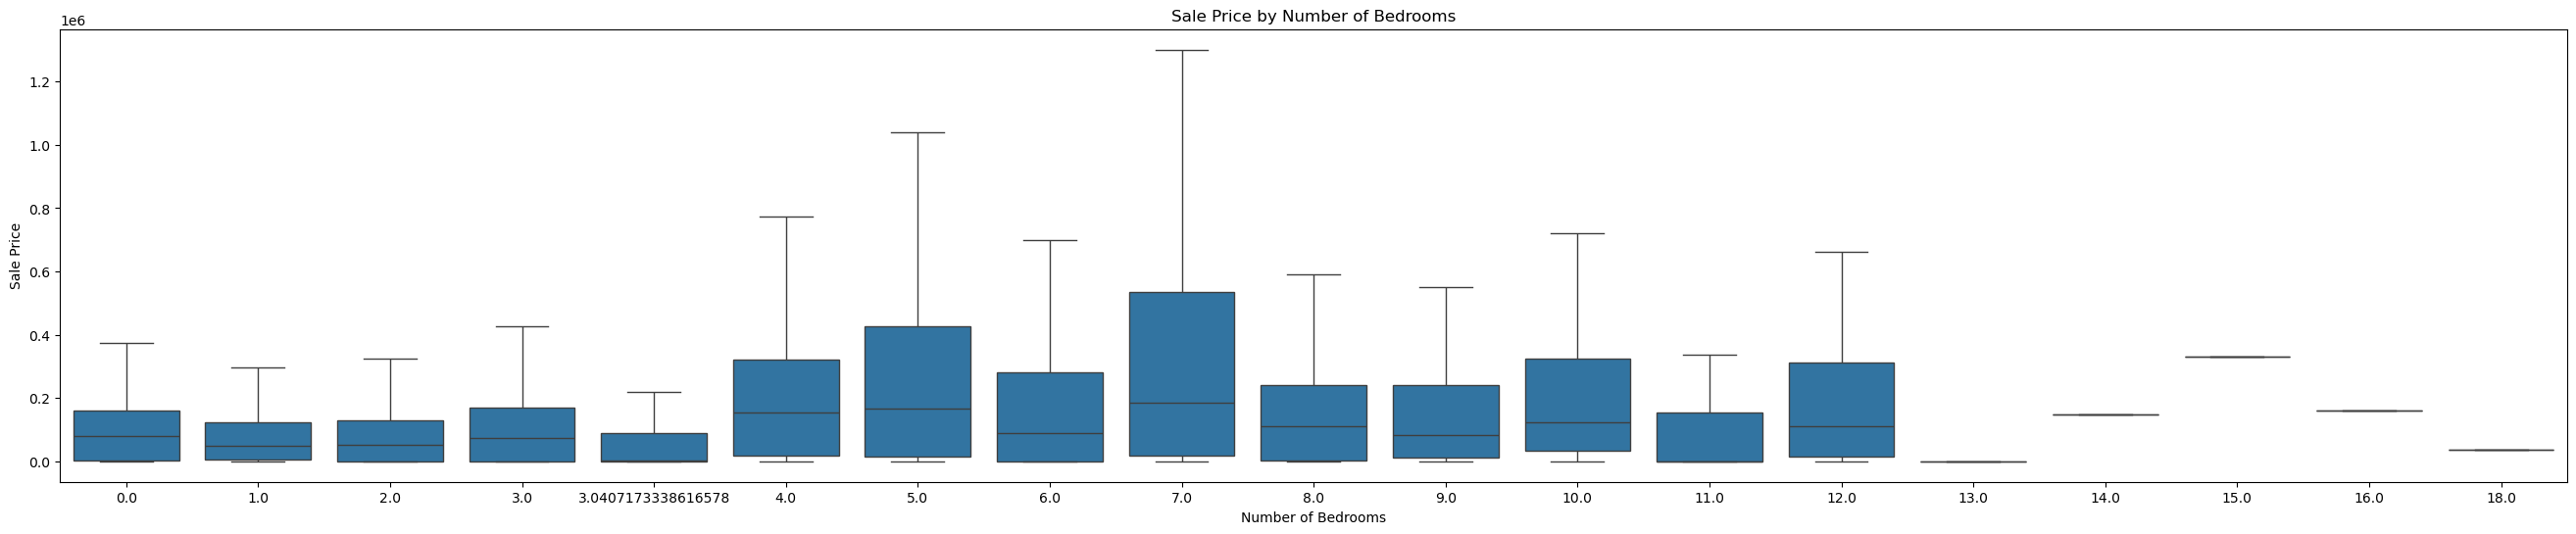

In [ ]:
# 17. How does **sale_price vary with number of bedrooms**?
plt.figure(figsize=(33,6))
sns.boxplot(x=df['bedrooms'], y=df['sale_price'], showfliers=False)
plt.title('Sale Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Sale Price')
plt.show()


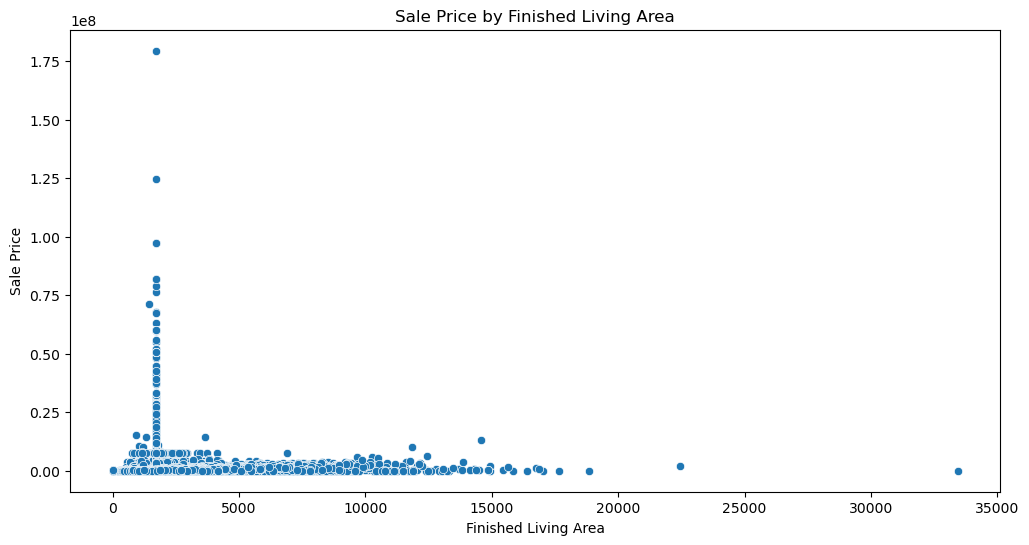

In [ ]:
# 18 Does **finished_living_area affect property price**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['finished_living_area'], y=df['sale_price'])
plt.title('Sale Price by Finished Living Area')
plt.xlabel('Finished Living Area')
plt.ylabel('Sale Price')
plt.show()


In [ ]:
# 19 What is the **average house size by city**?
avg_size_by_city = df.groupby('property_city')['finished_living_area'].mean().sort_values(ascending=False)
print("Average Finished Living Area by City:")
print(avg_size_by_city)

Average Finished Living Area by City:
property_city
BADEN         3186.727294
MARS          2979.681881
PRESTO        2881.986922
WEXFORD       2441.319921
SEWICKLEY     2410.343349
                 ...     
WHITAKER      1300.000000
INDIANOLA     1291.937019
WEST VIEW     1232.000000
WITAKER       1170.000000
PENN HILLS    1144.000000
Name: finished_living_area, Length: 105, dtype: float64


In [ ]:
# 20. How many **stories do most houses have**?
stories_distribution = df['stories'].value_counts()
print("Stories Distribution:")
print(stories_distribution)

Stories Distribution:
stories
2.000000    253354
1.000000    159439
1.640284    135648
1.500000     22843
2.500000      8503
3.000000      4969
1.800000        85
4.000000        21
1.700000        15
2.700000         7
2.800000         7
3.500000         5
Name: count, dtype: int64


In [ ]:
# 21. Which **building_style is most common**?
building_style_distribution = df['building_style_desc'].value_counts()
print("Building Style Distribution:")
print(building_style_distribution)

Building Style Distribution:
building_style_desc
OLD STYLE         251549
COLONIAL           95096
RANCH              72677
CAPE COD           40021
MULTI-FAMILY       21949
TOWNHOUSE          17621
BI-LEVEL           17132
SPLIT LEVEL        11269
SEMI DETACHED      10688
BUNGALOW            9234
ROW INTERIOR        6434
ROW END             4753
CONDO GRDN          4150
CONDO HR            3968
MANUFACTURED        3686
CONDO INT           3590
CONTEMPORARY        3143
CONDO PAT/CARG      2437
CONDO END           1991
TUDOR               1059
CONDO CONV           854
VICTORIAN            605
MODULAR HOME         263
CONDO                241
LOG CABIN            220
CONDO SINGLE         120
CONVENTIONAL         110
OTHER                 36
Name: count, dtype: int64


In [ ]:
# 22. Does **roof type affect property value**?
avg_price_by_roof_type = df.groupby('roof_type')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Roof Type:")
print(avg_price_by_roof_type)

Average Sale Price by Roof Type:
roof_type
6.000000    348955.919879
1.190076    237172.245076
5.000000    235656.379310
2.000000    208983.638654
4.000000    169717.831816
3.000000    161975.028964
1.000000    130826.495271
Name: sale_price, dtype: float64


In [ ]:
# 23. How many houses **have basements**?
basement_distribution = df['basement_type'].value_counts()
print("Basement Type Distribution:")
print(basement_distribution)

Basement Type Distribution:
basement_type
5.000000    406965
4.757283    135748
1.000000     18270
4.000000     16134
2.000000      4244
3.000000      3535
Name: count, dtype: int64


In [ ]:
# 24. Do houses with **fireplaces sell for higher prices**?
avg_price_by_fireplace = df.groupby('fireplaces')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Number of Fireplaces:")
print(avg_price_by_fireplace)

Average Sale Price by Number of Fireplaces:
fireplaces
9.000000     1.699976e+06
5.000000     1.469017e+06
4.000000     5.133520e+05
3.000000     5.119977e+05
6.000000     4.928079e+05
2.000000     2.821909e+05
0.376731     2.510114e+05
7.000000     2.183337e+05
1.000000     1.534200e+05
0.000000     9.650262e+04
8.000000     3.720000e+04
22.000000    1.000000e+01
12.000000    1.000000e+00
Name: sale_price, dtype: float64


## 4️⃣ Property Age Analysis

In [ ]:
# 25. What is the **average age of properties**?
current_year = pd.Timestamp.now().year
df['property_age'] = current_year - df['year_built']
print("Average Property Age:")
print(df['property_age'].mean())

Average Property Age:
76.679348176903


In [ ]:
# 26. What is the **average property age by neighborhood**?
avg_age_by_neighborhood = df.groupby('neighborhood_desc')['property_age'].mean().sort_values(ascending=False)
print("Average Property Age by Neighborhood:")
print(avg_age_by_neighborhood)

Average Property Age by Neighborhood:
neighborhood_desc
PRE-WAR MUNIS 121-127              129.000000
PIOUS ST LOFTS                     126.000000
CASIMIR                            125.000000
WARD 22 - NORTH SHORE/ALLEGHENY    123.813635
941 PENN AVENUE                    123.098785
                                      ...    
10501                               16.519928
LOCUST ST & LENOX PL                14.868421
HIGHLANDS                           14.463415
MEADOWS AT HAMPTON                  11.635615
BROSCIUS MOBILE H.P.                 1.000000
Name: property_age, Length: 561, dtype: float64


In [ ]:
# 27. What is the **average property age by municipality**?
avg_age_by_municipality = df.groupby('municipality_desc')['property_age'].mean().sort_values(ascending=False)
print("Average Property Age by Municipality:")
print(avg_age_by_municipality)

Average Property Age by Municipality:
municipality_desc
9th Ward - PITTSBURGH     111.716494
30th Ward - PITTSBURGH    109.054823
22nd Ward - PITTSBURGH    106.385851
Millvale                  104.653016
16th Ward - PITTSBURGH    104.274299
                             ...    
South Fayette              48.208846
Franklin Park              45.190117
Marshall                   39.611531
Pine                       37.744362
Ohio                       37.281964
Name: property_age, Length: 175, dtype: float64


In [ ]:
# 28. Which **property class has the highest average sale price**?
avg_price_by_property_class = df.groupby('property_class_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Property Class:")
print(avg_price_by_property_class)

Average Sale Price by Property Class:
property_class_desc
OTHER           1.241126e+06
COMMERCIAL      6.311325e+05
INDUSTRIAL      5.732129e+05
RESIDENTIAL     1.267469e+05
UTILITIES       1.252899e+05
AGRICULTURAL    1.139851e+05
GOVERNMENT      6.031486e+04
Name: sale_price, dtype: float64


## 5️⃣ Tax Assessment Analysis

In [ ]:
# 29. What is the **average county_total_value**?
avg_county_total_value = df['county_total_value'].mean()
print(f"Average County Total Value: ${avg_county_total_value:,.2f}")

Average County Total Value: $183,295.94


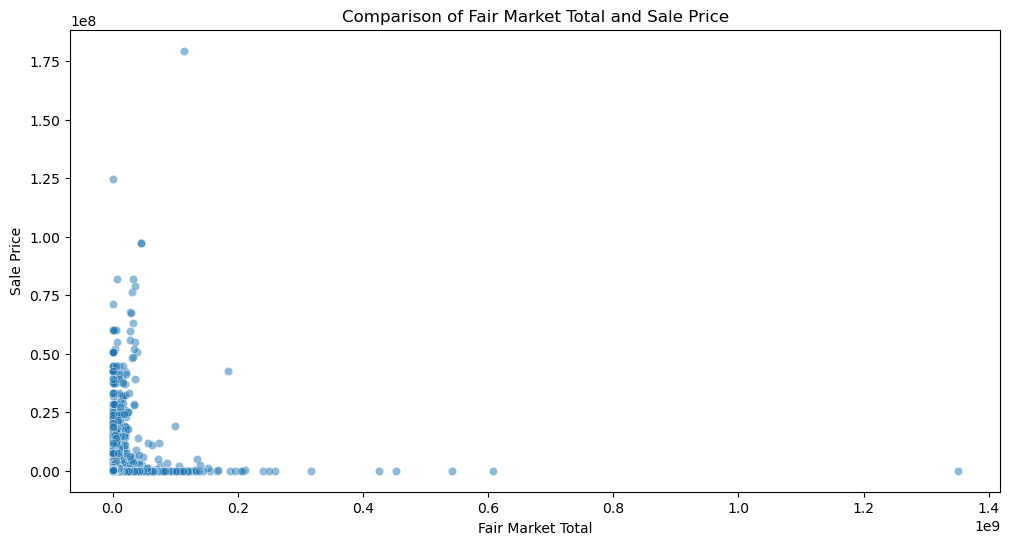

In [ ]:
# 30. How does **fair_market_total compare with sale_price**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['fair_market_total'], y=df['sale_price'], alpha=0.5)
plt.xlabel('Fair Market Total')
plt.ylabel('Sale Price')
plt.title('Comparison of Fair Market Total and Sale Price')
plt.show()

In [ ]:
# 31 Which **city has the highest assessed property value**?
max_assessed_value = df['county_total_value'].max()
city_with_max_assessed_value = df[df['county_total_value'] == max_assessed_value]['property_city'].iloc[0]
print(f"City with Highest Assessed Property Value: {city_with_max_assessed_value}")

City with Highest Assessed Property Value: IMPERIAL


In [ ]:
# 32. What percentage of properties have **tax exemptions**?
tax_exemption_percentage = (df['county_exempt_building'].sum() / len(df)) * 100
print(f"Percentage of properties with tax exemptions: {tax_exemption_percentage:.2f}%")

Percentage of properties with tax exemptions: 325478.63%


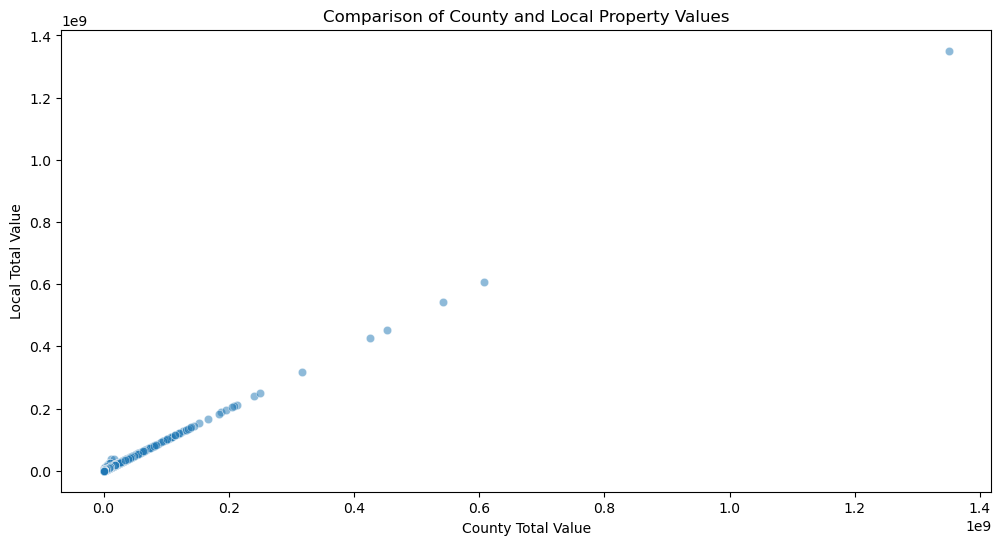

In [ ]:
# 33. How do **county values compare with local values**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['county_total_value'], y=df['local_total_value'], alpha=0.5)
plt.xlabel('County Total Value')
plt.ylabel('Local Total Value')
plt.title('Comparison of County and Local Property Values')
plt.show()

### 6️⃣ Land & Area Analysis

In [ ]:
# 34. What is the **average lot size by city**?
avg_lot_size_by_city = df.groupby('property_city')['lot_area'].mean().sort_values(ascending=False)
print("Average Lot Size by City:")
print(avg_lot_size_by_city)

Average Lot Size by City:
property_city
SAXONBURG      1.513274e+06
MCDONALD       4.160503e+05
MONONGAHELA    3.018581e+05
BUNOLA         2.329253e+05
IMPERIAL       1.891567e+05
                   ...     
ASPINWALL      4.433333e+03
RANKIN         3.972600e+03
WITAKER        3.872000e+03
MOON TWP       3.093000e+03
SHARPSBURG     1.633000e+03
Name: lot_area, Length: 105, dtype: float64


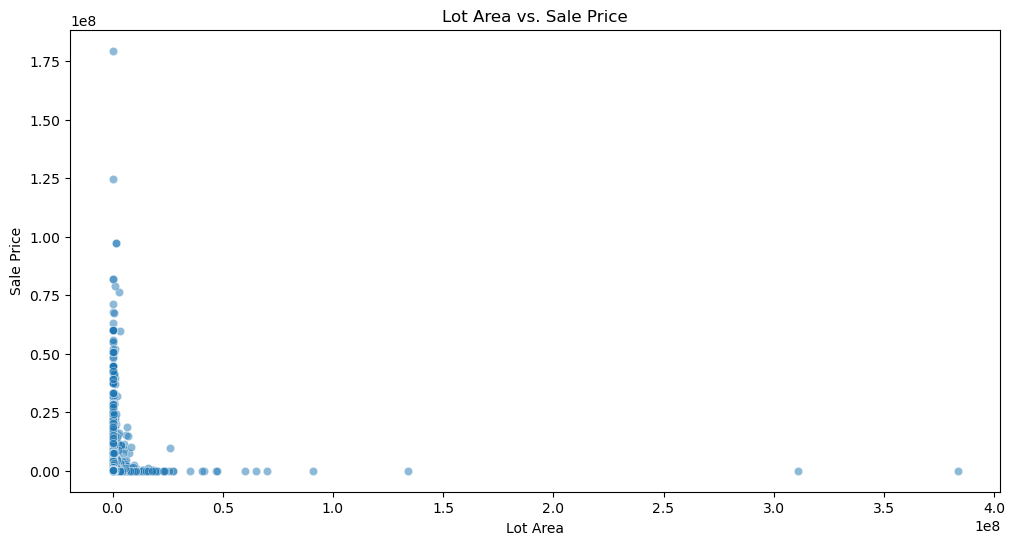

In [ ]:
# 35. Do **larger lots lead to higher sale prices**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['lot_area'], y=df['sale_price'], alpha=0.5)
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.title('Lot Area vs. Sale Price')
plt.show()

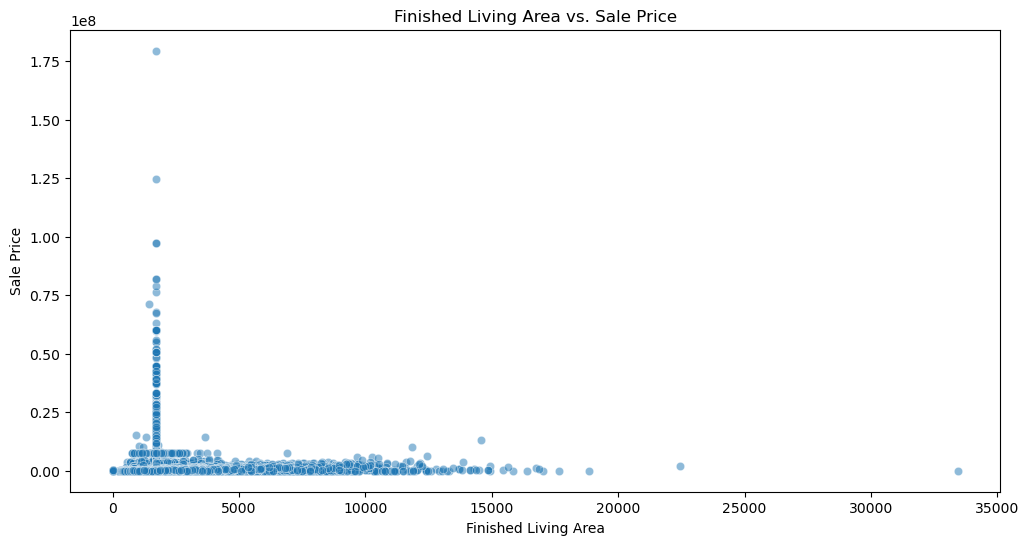

In [ ]:
# 36. What is the **relationship between living area and sale price**?
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['finished_living_area'], y=df['sale_price'], alpha=0.5)
plt.xlabel('Finished Living Area')
plt.ylabel('Sale Price')
plt.title('Finished Living Area vs. Sale Price')
plt.show()

In [ ]:
# 37. Which **property class has the most expensive properties**?
avg_price_by_property_class = df.groupby('property_class_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Property Class:")
print(avg_price_by_property_class)

Average Sale Price by Property Class:
property_class_desc
OTHER           1.241126e+06
COMMERCIAL      6.311325e+05
INDUSTRIAL      5.732129e+05
RESIDENTIAL     1.267469e+05
UTILITIES       1.252899e+05
AGRICULTURAL    1.139851e+05
GOVERNMENT      6.031486e+04
Name: sale_price, dtype: float64


### 7️⃣ Housing Quality Analysis

In [ ]:
# 38. How does **property condition affect sale price**?
avg_price_by_condition = df.groupby('condition_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Property Condition:")
print(avg_price_by_condition)

Average Sale Price by Property Condition:
condition_desc
EXCELLENT    559100.469933
VERY GOOD    495015.647324
GOOD         287106.527752
AVERAGE      156147.280559
FAIR          65616.750373
POOR          49986.265367
VERY POOR     37021.834347
UNSOUND       28424.246006
Name: sale_price, dtype: float64


In [ ]:
# 39. What is the **average sale price for properties with and without basements**?
avg_price_by_basement = df.groupby('basement_type')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Basement Type:")
print(avg_price_by_basement)

Average Sale Price by Basement Type:
basement_type
2.000000    237946.379422
4.757283    237181.401086
1.000000    165178.085372
5.000000    134716.794973
4.000000    126389.895216
3.000000    125586.069759
Name: sale_price, dtype: float64


In [ ]:
# 40. How does **property style affect sale price**?
avg_price_by_style = df.groupby('building_style_desc')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Building Style:")
print(avg_price_by_style)

Average Sale Price by Building Style:
building_style_desc
CONDO             463419.144153
VICTORIAN         345002.358249
CONDO SINGLE      319979.008333
TUDOR             293379.017697
CONTEMPORARY      284987.208612
CONDO HR          245224.200941
CONDO CONV        232553.803192
TOWNHOUSE         222903.704786
CONVENTIONAL      219357.248822
COLONIAL          213224.037708
CONDO PAT/CARG    196838.845955
CONDO END         189677.121659
OLD STYLE         171054.646678
CONDO INT         157723.593449
OTHER             157661.760288
MULTI-FAMILY      138595.270995
ROW END           137510.869977
ROW INTERIOR      135164.032219
SEMI DETACHED     128923.997231
LOG CABIN         128169.206229
SPLIT LEVEL       126049.415184
CONDO GRDN        118249.448229
MANUFACTURED      117837.530320
BI-LEVEL          108015.353806
RANCH             101853.337300
CAPE COD          101144.954755
MODULAR HOME       76764.672441
BUNGALOW           51042.726141
Name: sale_price, dtype: float64


In [ ]:
# 41. What is the **average sale price for properties with different roof types**?
avg_price_by_roof_type = df.groupby('roof_type')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Roof Type:")
print(avg_price_by_roof_type)

Average Sale Price by Roof Type:
roof_type
6.000000    348955.919879
1.190076    237172.245076
5.000000    235656.379310
2.000000    208983.638654
4.000000    169717.831816
3.000000    161975.028964
1.000000    130826.495271
Name: sale_price, dtype: float64


### 8️⃣ Feature-Based Analysis

In [ ]:
# 42. Do houses with **basement_garage sell for more**?
avg_price_by_basement_garage = df.groupby('basement_garage')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Basement Garage Presence:")
print(avg_price_by_basement_garage)

Average Sale Price by Basement Garage Presence:
basement_garage
6.000000    350759.791667
3.000000    282788.399695
5.000000    273411.979592
4.000000    271845.008901
0.705458    252313.885101
2.000000    178956.067628
0.000000    115227.646331
1.000000     98154.437807
Name: sale_price, dtype: float64


In [ ]:
# 43. Do houses with **more bathrooms sell for more**?
avg_price_by_bathrooms = df.groupby('full_baths')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Number of Full Bathrooms:")
print(avg_price_by_bathrooms)

Average Sale Price by Number of Full Bathrooms:
full_baths
9.000000     1.163302e+06
7.000000     1.027760e+06
6.000000     7.560571e+05
8.000000     7.507195e+05
5.000000     7.248538e+05
4.000000     4.346992e+05
3.000000     3.337302e+05
1.502875     2.369656e+05
2.000000     1.779773e+05
1.000000     8.435927e+04
0.000000     6.486056e+04
12.000000    4.210000e+04
13.000000    1.000000e+01
10.000000    1.000000e+00
Name: sale_price, dtype: float64


In [ ]:
# 44. How many houses have **heating_cooling systems**?
heating_cooling_distribution = df['heating_cooling_desc'].value_counts()
print("Heating and Cooling System Distribution:")
print(heating_cooling_distribution)

Heating and Cooling System Distribution:
heating_cooling_desc
Central Heat with AC     406295
Central Heat             174098
Other                       904
Heat Pump with AC           779
Electric Heat with AC       676
Unit Heat                   625
Electric                    496
Heat Pump                   434
Wall Furnace                211
Floor Furnace               166
Wall Furnace with AC         72
Unit Heat with AC            71
No Heat but with AC          53
Floor Furnace with AC        16
Name: count, dtype: int64


In [ ]:
# 45. Does **number of rooms impact sale price**?
avg_price_by_rooms = df.groupby('total_rooms')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Total Number of Rooms:")
print(avg_price_by_rooms)

Average Sale Price by Total Number of Rooms:
total_rooms
19.000000    1.279000e+06
13.000000    3.727989e+05
11.000000    3.585699e+05
58.000000    3.500000e+05
14.000000    3.348581e+05
17.000000    3.257735e+05
15.000000    2.940791e+05
18.000000    2.825976e+05
10.000000    2.778204e+05
20.000000    2.775765e+05
9.000000     2.746931e+05
12.000000    2.712299e+05
22.000000    2.660001e+05
24.000000    2.635650e+05
6.487656     2.371158e+05
16.000000    2.258393e+05
8.000000     2.030902e+05
21.000000    1.921677e+05
65.000000    1.836000e+05
27.000000    1.750000e+05
25.000000    1.553340e+05
87.000000    1.522667e+05
7.000000     1.389709e+05
23.000000    1.350007e+05
1.000000     1.339064e+05
51.000000    1.300000e+05
36.000000    1.236000e+05
53.000000    1.150000e+05
56.000000    1.105000e+05
2.000000     1.046009e+05
6.000000     1.032663e+05
5.000000     9.254078e+04
3.000000     9.098984e+04
4.000000     8.740992e+04
32.000000    8.000000e+04
0.000000     6.149154e+04
30.0000

### 9️⃣ Time-Based Analysis

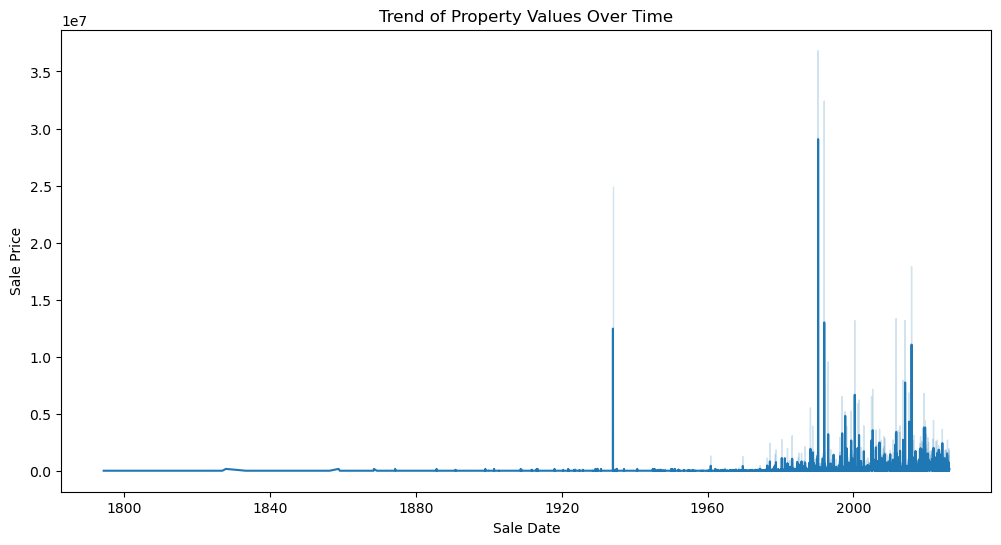

In [ ]:
# 46. What is the **trend of property values over time**?
df['sale_date'] = pd.to_datetime(df['sale_date'])
df = df.sort_values('sale_date')
plt.figure(figsize=(12,6))
sns.lineplot(x=df['sale_date'], y=df['sale_price'])
plt.title('Trend of Property Values Over Time')
plt.xlabel('Sale Date')
plt.ylabel('Sale Price')
plt.show()

In [ ]:
# 47. How many properties were **recorded each year**?
df['sale_year'] = df['sale_date'].dt.year
properties_by_year = df['sale_year'].value_counts().sort_index()
print("Number of Properties Recorded Each Year:")
print(properties_by_year)


Number of Properties Recorded Each Year:
sale_year
1794        1
1797        1
1806        1
1809        1
1811        1
        ...  
2022    27225
2023    25176
2024    26771
2025    28986
2026     4484
Name: count, Length: 192, dtype: int64


In [ ]:
# 48. What is the **average sale price per tax_year**?
avg_price_by_tax_year = df.groupby('tax_year')['sale_price'].mean().sort_index()
print("Average Sale Price per Tax Year:")
print(avg_price_by_tax_year)

Average Sale Price per Tax Year:
tax_year
2026    159913.370378
Name: sale_price, dtype: float64


### 🔟 Data Quality Questions (EDA)

In [ ]:
# 49. Which columns have the **most missing values**?
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent_sort = missing_percent.sort_values(ascending=False)
print("Percentage of Missing Values by Column:")
print(missing_percent_sort)

Percentage of Missing Values by Column:
id                      0.0
building_style          0.0
roof_desc               0.0
roof_type               0.0
exterior_finish_desc    0.0
                       ... 
lot_area                0.0
use_desc                0.0
use_code                0.0
property_class_desc     0.0
sale_year               0.0
Length: 78, dtype: float64


In [ ]:
# 50. Are there **duplicate parcel_id records**?
duplicate_parcel_ids = df['parcel_id'].duplicated().sum()
print(f"Number of duplicate parcel_id records: {duplicate_parcel_ids}")

Number of duplicate parcel_id records: 0


In [ ]:
# 51. What is the **correlation between numeric features**?
correlation_matrix = df[num_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                               id  property_house_num  property_zip  \
id                       1.000000           -0.003712     -0.128158   
property_house_num      -0.003712            1.000000      0.040375   
property_zip            -0.128158            0.040375      1.000000   
municipality_code        0.558372           -0.060008     -0.257505   
school_code             -0.285092            0.034157      0.248538   
owner_code              -0.113664           -0.046421      0.028232   
use_code                -0.159683           -0.077716      0.016919   
lot_area                 0.012868           -0.003737     -0.017960   
sale_price               0.004185            0.017837      0.017935   
prev_sale_price          0.006556            0.001665      0.005111   
change_notice_address_4 -0.029652           -0.003252      0.018800   
county_building_value   -0.004104            0.015225      0.009015   
county_land_value       -0.000673            0.003035    

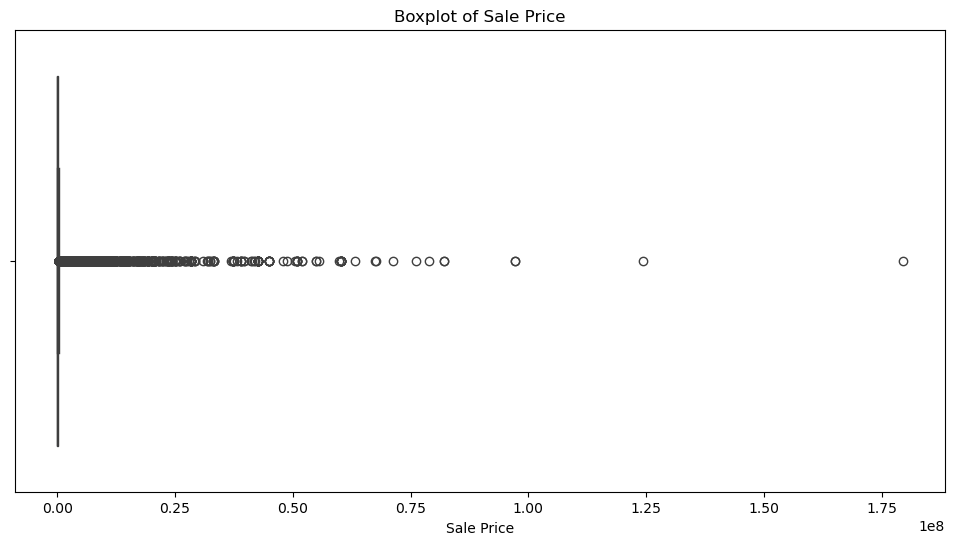

In [ ]:
# 52. Are there **outliers in sale_price**?
plt.figure(figsize=(12,6))
sns.boxplot(x=df['sale_price'])
plt.title('Boxplot of Sale Price')
plt.xlabel('Sale Price')
plt.show()

In [ ]:
# 53. Are there **inconsistent values in property_city or zip codes**?
print("Unique values in property_city:")
print(df['property_city'].unique())
print("Unique values in zip_code:")

Unique values in property_city:
['OAKDALE' 'PITTSBURGH' 'TURTLE CREEK' 'BRIDGEVILLE' 'EAST MC KEESPORT'
 'TARENTUM' 'BAKERSTOWN' 'CORAOPOLIS' 'SEWICKLEY' 'GIBSONIA' 'BRADDOCK'
 'MC KEES ROCKS' 'GREENOCK' 'MC DONALD' 'MC KEESPORT' 'CLAIRTON'
 'ELIZABETH' 'COULTERS' 'BRACKENRIDGE' 'WEST MIFFLIN' 'BUENA VISTA'
 'CARNEGIE' 'HOMESTEAD' 'NATRONA HEIGHTS' 'SOUTH PARK' 'NORTH VERSAILLES'
 'WALL' 'VERONA' 'MONROEVILLE' 'CLINTON' 'EAST PITTSBURGH' 'CREIGHTON'
 'NEW KENSINGTON' 'MONONGAHELA' 'BETHEL PARK' 'BUNOLA' 'CHESWICK'
 'DRAVOSBURG' 'FINLEYVILLE' 'DUQUESNE' 'WILMERDING' 'CRESCENT' 'GLENSHAW'
 'ALLISON PARK' 'PITCAIRN' 'WEST ELIZABETH' 'STURGEON' 'GLASSPORT' 'CUDDY'
 'OAKMONT' 'WEST NEWTON' 'LEETSDALE' 'MCKEESPORT' 'AMBRIDGE' 'IMPERIAL'
 'CECIL' 'VALENCIA' 'PRESTO' 'WEXFORD' 'BADEN' 'TRAFFORD' 'SPRINGDALE'
 'MORGAN' 'WEST HOMESTEAD' 'INDIANOLA' 'SUTERSVILLE' 'HARWICK'
 'BRADFORD WOODS' 'BAIRDFORD' 'RUSSELLTON' 'WARRENDALE' 'RURAL RIDGE'
 'MARS' 'MCDONALD' 'WHITAKER' 'MURRYSVILLE' 'WHITE OAK'

### ⭐ Advanced Analysis Questions (Best for ML Projects)

In [ ]:
# 54. Can we **predict sale_price using property features**?